In [1]:
!pip install -q pystats
import pystats
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.6/335.6 kB 6.5 MB/s eta 0:00:00


In [3]:
marks=[
    42, 55, 67, 71, 48, 83, 76, 59, 64, 91,
    52, 68, 74, 81, 57, 63, 69, 77, 85, 46,
    61, 72, 79, 88, 54, 66, 73, 82, 58, 70
]
print("="* 65)
print("Descriptive Statistical Analysis")
print("="* 65)
print("\n Dataset:",marks)


Descriptive Statistical Analysis

 Dataset: [42, 55, 67, 71, 48, 83, 76, 59, 64, 91, 52, 68, 74, 81, 57, 63, 69, 77, 85, 46, 61, 72, 79, 88, 54, 66, 73, 82, 58, 70]


In [6]:
#no.of observations
n=len(marks)
print("no.of observations",n)
#min() gives the smallest mark
minimum=min(marks)
print("the smallest mark",minimum)
#max() gives the largest
maximum=max(marks)
print("the largest",maximum)
#range
range=maximum-minimum
print("range:",range)

no.of observations 30
the smallest mark 42
the largest 91
range: 49


In [7]:
#pystats mean()
mean=pystats.mean(marks)
sorted_marks=sorted(marks)
#meadian
median=(sorted_marks[14]+sorted_marks[15])/2
#frequency
frequency={}
for mark in marks:
  if mark in frequency:
    frequency[mark]+=1
  else:
    frequency[mark]=1
#highest frequency
maximum_frequency=max(frequency.values())
if maximum_frequency==1:
  mode="no unique mode"
else:
  mode=[ value for value,freq in frequency.items()
         if freq==maximum_frequency
         ]
print("\n\nQUESTION 2")
print("-" * 40)
print("Mean =", mean)
print("Median =", median)
print("Mode =", mode)





QUESTION 2
----------------------------------------
Mean = 67.7
Median = 68.5
Mode = no unique mode


In [8]:
def percentile(data, p):

    # Sort the data
    x = sorted(data)

    # Number of observations
    n = len(x)

    # Position using the (n-1)*p method
    position = (n - 1) * p

    # Lower index
    lower = int(position)

    # Upper index
    upper = lower + 1

    # If position is an exact integer
    if upper >= n:
        return x[lower]

    # Fractional part
    fraction = position - lower

    # Linear interpolation
    return x[lower] + fraction * (x[upper] - x[lower])


Q1 = percentile(marks, 0.25)
Q2 = percentile(marks, 0.50)
Q3 = percentile(marks, 0.75)

# IQR = Q3 - Q1
IQR = Q3 - Q1

print("\n\nQUESTION 3")
print("-" * 40)
print("Q1 =", Q1)
print("Q2 =", Q2)
print("Q3 =", Q3)
print("IQR =", IQR)





QUESTION 3
----------------------------------------
Q1 = 58.25
Q2 = 68.5
Q3 = 76.75
IQR = 18.5


In [9]:
# PyStats var() calculates SAMPLE variance
variance = pystats.var(marks)

# PyStats sd() calculates SAMPLE standard deviation
standard_deviation = pystats.sd(marks)

# Coefficient of Variation:
# CV = (Standard Deviation / Mean) * 100
CV = (standard_deviation / mean) * 100

print("\n\nQUESTION 4")
print("-" * 40)
print("Sample Variance =", variance)
print("Sample Standard Deviation =", standard_deviation)
print("Coefficient of Variation =", CV, "%")





QUESTION 4
----------------------------------------
Sample Variance = 163.4586206896547
Sample Standard Deviation = 12.785093691078478
Coefficient of Variation = 18.884924211341918 %


In [10]:
P10 = percentile(marks, 0.10)
P25 = percentile(marks, 0.25)
P50 = percentile(marks, 0.50)
P75 = percentile(marks, 0.75)
P90 = percentile(marks, 0.90)

print("\n\nQUESTION 5")
print("-" * 40)
print("10th Percentile =", P10)
print("25th Percentile =", P25)
print("50th Percentile =", P50)
print("75th Percentile =", P75)
print("90th Percentile =", P90)




QUESTION 5
----------------------------------------
10th Percentile = 51.6
25th Percentile = 58.25
50th Percentile = 68.5
75th Percentile = 76.75
90th Percentile = 83.2


In [11]:
# Calculate skewness manually using the
# bias-corrected sample skewness formula.

N = len(marks)

# Calculate deviations from mean
deviations = [x - mean for x in marks]

# Sum of squared deviations
sum_squared = sum(d ** 2 for d in deviations)

# Sum of cubed deviations
sum_cubed = sum(d ** 3 for d in deviations)

# Sample standard deviation
s = standard_deviation

# Bias-corrected Fisher-Pearson sample skewness
skewness = (
    (N / ((N - 1) * (N - 2)))
    * (sum_cubed / (s ** 3))
)

print("\n\nQUESTION 6")
print("-" * 40)
print("Skewness =", skewness)




QUESTION 6
----------------------------------------
Skewness = -0.144717475071744


In [12]:
# Calculate the fourth central moment
fourth_moment = sum(
    (x - mean) ** 4 for x in marks
) / N

# Population-style second central moment
second_moment = sum(
    (x - mean) ** 2 for x in marks
) / N

# Excess kurtosis
kurtosis = (
    fourth_moment / (second_moment ** 2)
) - 3

print("\n\nQUESTION 7")
print("-" * 40)
print("Excess Kurtosis =", kurtosis)





QUESTION 7
----------------------------------------
Excess Kurtosis = -0.7645303079544079


In [13]:
# Five-number summary
print("\n\nQUESTION 8")
print("-" * 40)

print("Minimum =", minimum)
print("Q1 =", Q1)
print("Median =", Q2)
print("Q3 =", Q3)
print("Maximum =", maximum)

# 1.5 × IQR rule

# Lower fence
lower_fence = Q1 - 1.5 * IQR

# Upper fence
upper_fence = Q3 + 1.5 * IQR

print("\nLower Fence =", lower_fence)
print("Upper Fence =", upper_fence)

# Find observations outside the fences
outliers = [
    x for x in marks
    if x < lower_fence or x > upper_fence
]

print("Potential Outliers =", outliers)

if len(outliers) == 0:
    print("Conclusion: No potential outliers.")
else:
    print("Conclusion: Potential outliers are present.")




QUESTION 8
----------------------------------------
Minimum = 42
Q1 = 58.25
Median = 68.5
Q3 = 76.75
Maximum = 91

Lower Fence = 30.5
Upper Fence = 104.5
Potential Outliers = []
Conclusion: No potential outliers.


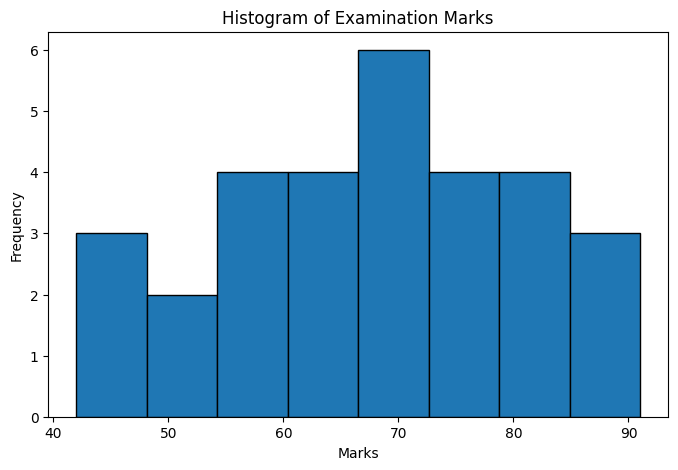

In [14]:
plt.figure(figsize=(8, 5))

# Draw histogram
plt.hist(
    marks,
    bins=8,
    edgecolor="black"
)

plt.title("Histogram of Examination Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.show()


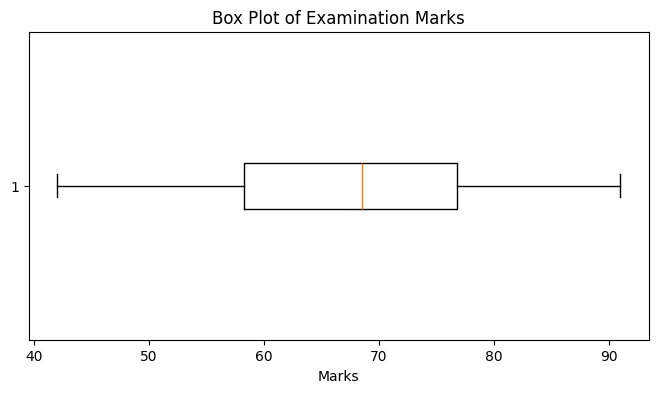

In [15]:
plt.figure(figsize=(8, 4))

# Draw horizontal box plot
plt.boxplot(
    marks,
    vert=False
)

plt.title("Box Plot of Examination Marks")
plt.xlabel("Marks")

plt.show()

Conlusion:
The examination marks of the 30 students have a mean of 67.7 and a median of 68.5, indicating that the typical performance is around 68 marks. The standard deviation is approximately 12.79, with a coefficient of variation of 18.88%, indicating moderate variability in student performance. The middle 50% of marks lie between 58.25 and 76.75, giving an IQR of 18.5. The distribution is slightly negatively skewed and platykurtic, as indicated by the skewness of approximately −0.145 and excess kurtosis of approximately −0.679. The 1.5 × IQR rule and box plot indicate that there are no potential outliers in the dataset.